# Generative modeling for SFC data (Flow Matching).

In this notebook we will fit an unconditional Flow Matching Model on a subsample of the dataset.

## Libraries and Data.


### Importing the libraries.

In [1]:
from anndata import AnnData
from matplotlib import rcParams
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scanpy as sc
import torch

from sc_exp_design.config import NeuralVelocityFieldConfig
from sc_exp_design.models import FlowMatching

# defining figure size
FIGSIZE = (3, 3)
rcParams["figure.figsize"] = FIGSIZE


### Reading the data.

In [2]:
PATH = "../../theis/HID01_fcs_concatenated.h5ad"
adata = sc.read_h5ad(PATH)
adata


AnnData object with n_obs × n_vars = 93278696 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'

### Subsampling the data.

In [3]:
# optionally subsample the data
KEEP_COPY = True
SUBSAMPLE = True
SUBSAMPLING_DONE = False
SUBSAMPLE_SIZE = 1e-2

if SUBSAMPLE and not SUBSAMPLING_DONE:
    if KEEP_COPY:
        adata_original = adata.copy()
        sc.pp.subsample(adata, SUBSAMPLE_SIZE)
    SUBSAMPLING_DONE = True
adata


AnnData object with n_obs × n_vars = 932786 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'

### Applying Tranformation.

In this example we will apply $\text{arcsinh}$ scaling to the data with a cofactor of $\lambda = 10,000$.

In [4]:
cofactor = 100
key_arcsin = f"X_arcsinh_cof{cofactor}" 
adata.obsm[key_arcsin] = np.arcsinh(adata.X/cofactor)
adata


AnnData object with n_obs × n_vars = 932786 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'
    obsm: 'X_arcsinh_cof100'

### Computing PCs, Neighbours graph and UMAP.

In [ ]:
SUBSAMPLE_SIZE = 5e-1
adata_umap = adata.copy()
sc.pp.subsample(adata_umap, SUBSAMPLE_SIZE)
adata_umap.layers[key_arcsin] = adata_umap.obsm[key_arcsin]
sc.pp.pca(adata_umap, layer=key_arcsin)
sc.pp.neighbors(adata_umap)
sc.pp.neighbors(adata_umap)
sc.tl.umap(adata_umap)


### Visualizing data with PCA and UMAP.


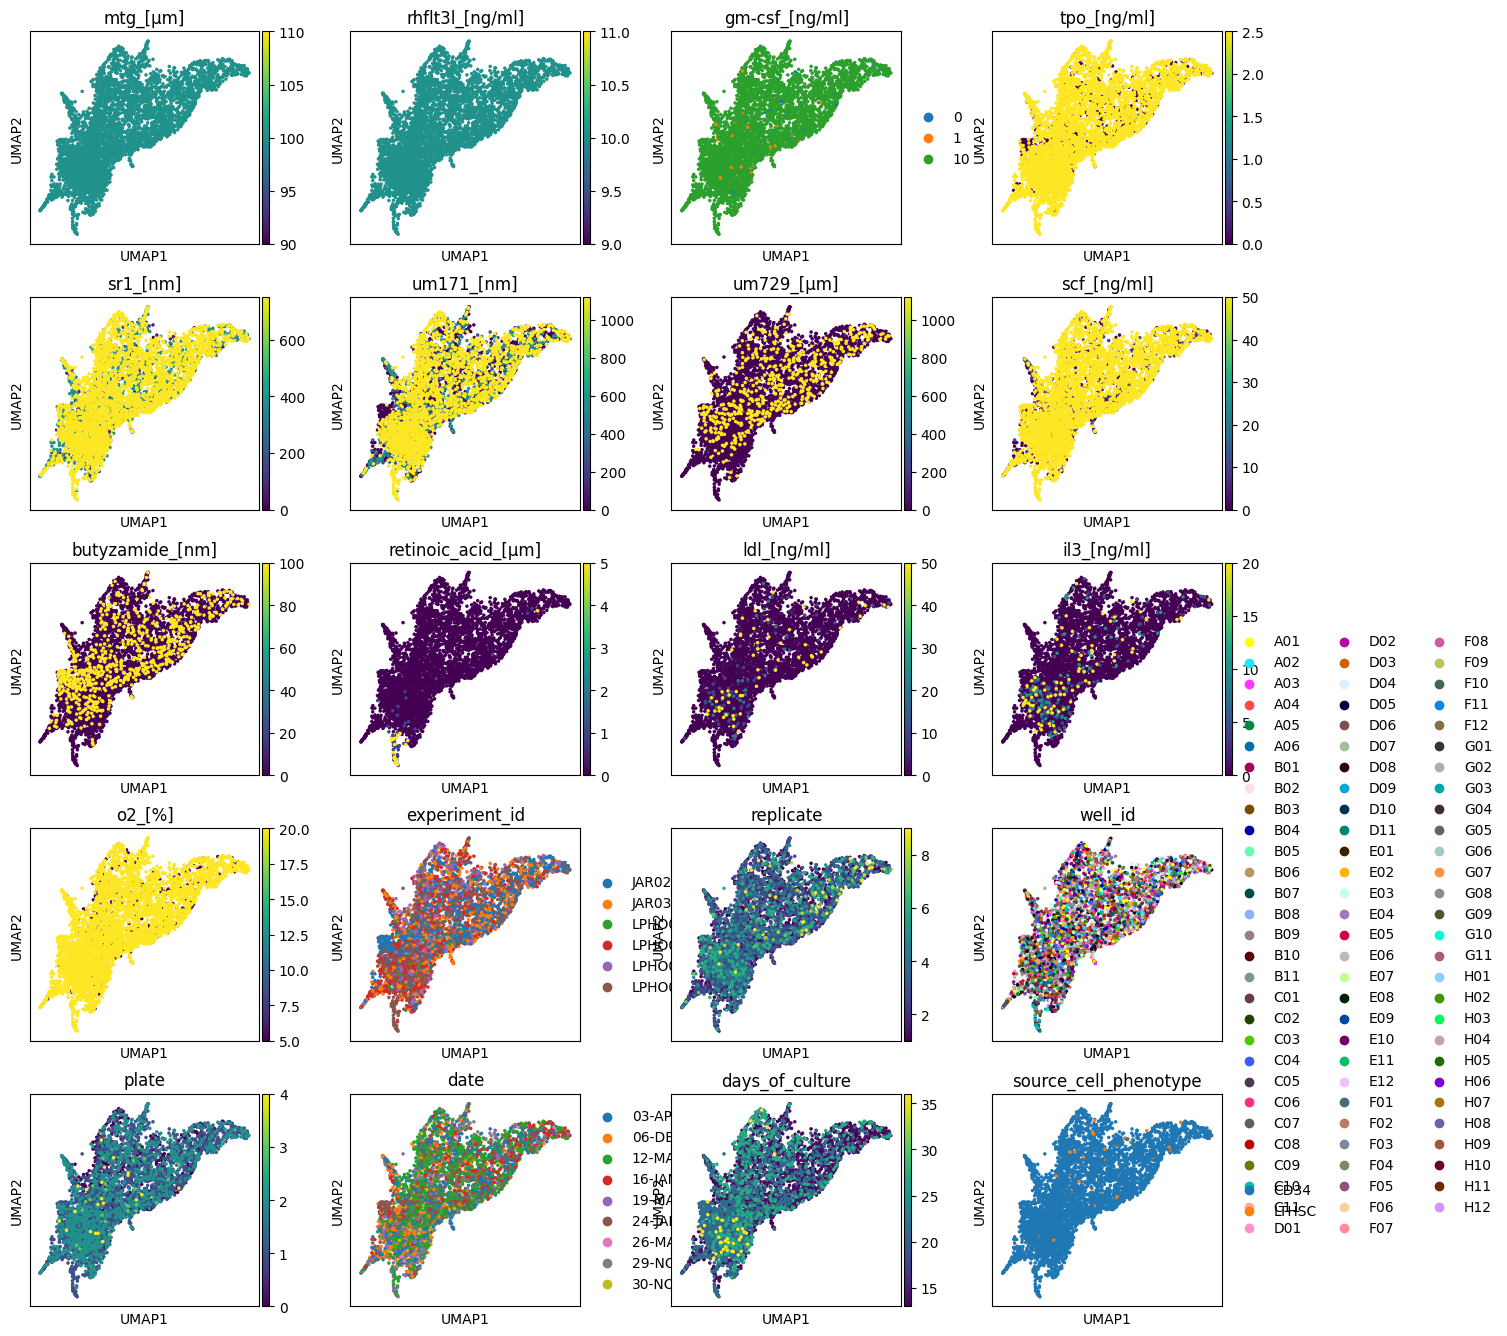

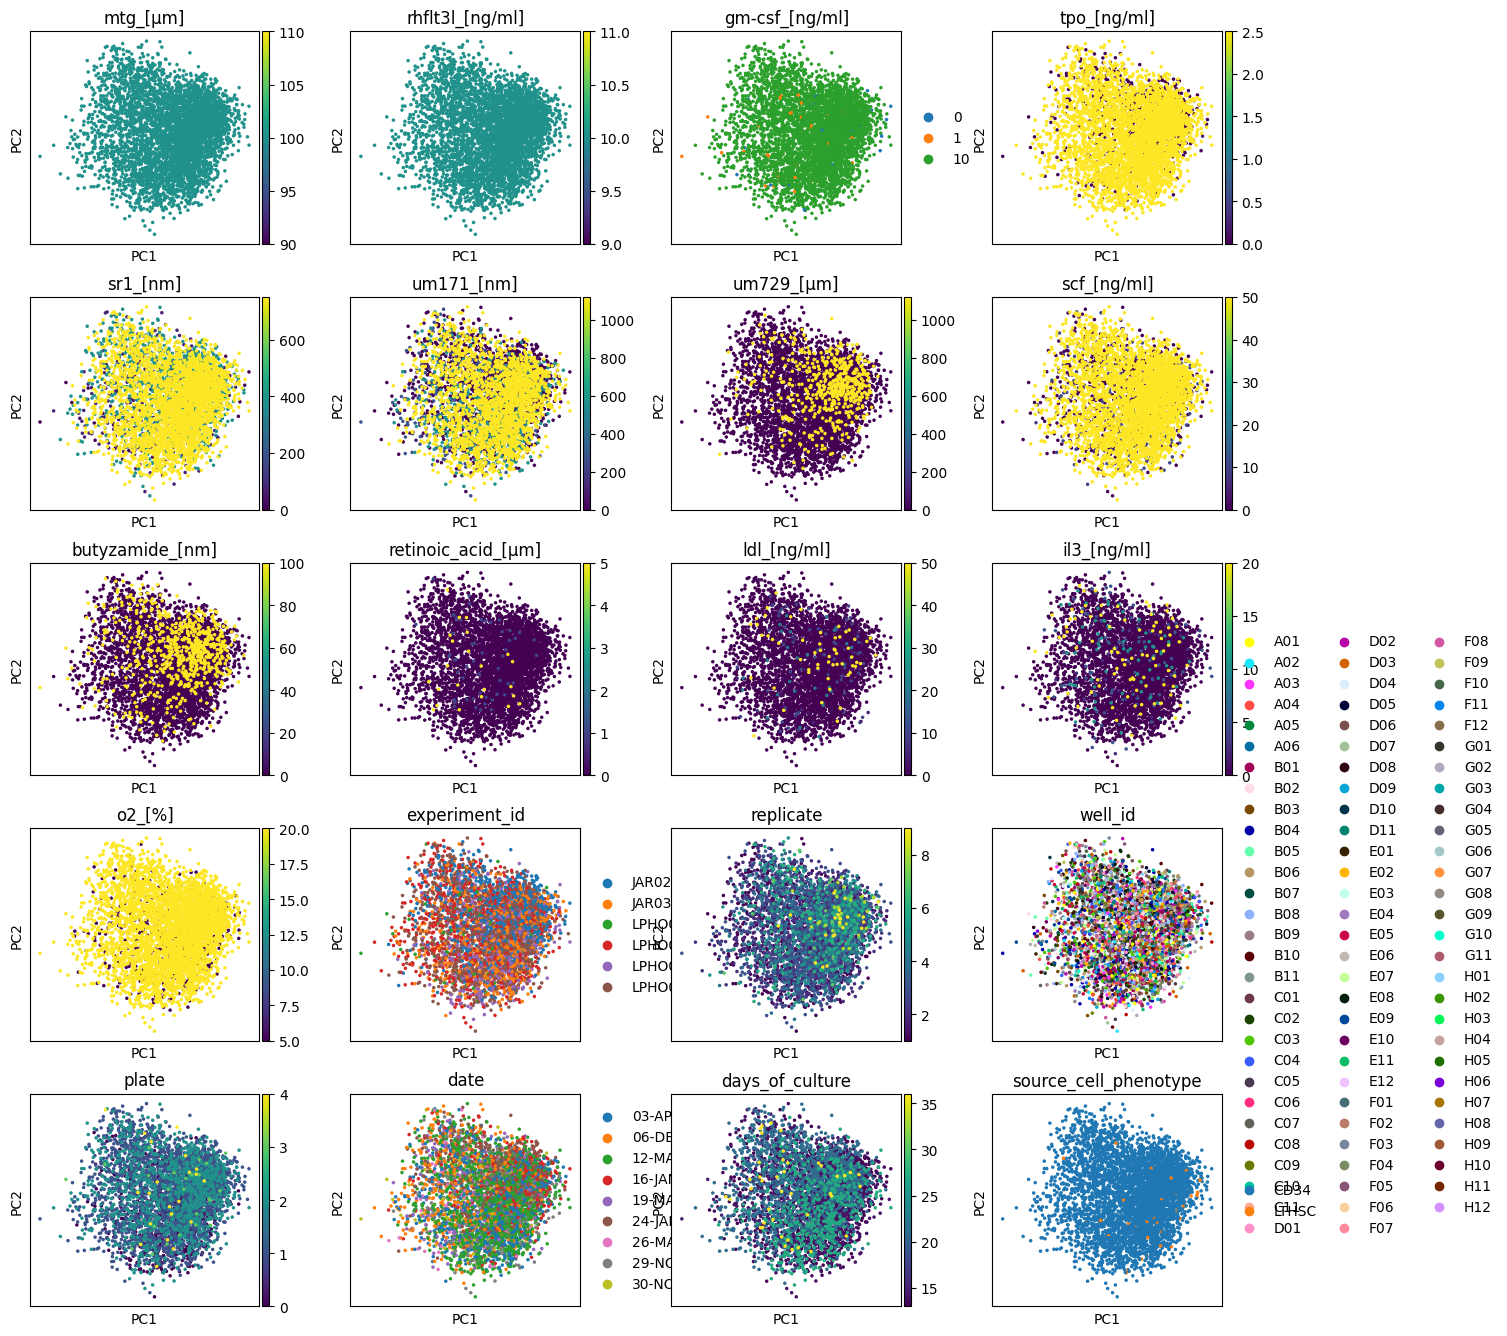

In [ ]:
EXPERIMENTAL_COLUMNS = [
    'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]',
    'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]',
    'ldl_[ng/ml]', 'il3_[ng/ml]', 'o2_[%]',
] + ["experiment_id", "replicate", "well_id", "plate", "date", "days_of_culture", "source_cell_phenotype"]
sc.pl.umap(adata_umap, color=EXPERIMENTAL_COLUMNS)
sc.pl.pca(adata_umap, color=EXPERIMENTAL_COLUMNS)


## Model.

### Initializing Flow Matching Model.

We will instatiate a very simple model with independent coudpling and generation from a standard gaussian distribution.

In [6]:
flow_matching = FlowMatching(
    coupling_type="independent",
    generate_from_noise=True,
)


### Preparing the data.

To prepare the data we only need to pass the identifier for the samples representation.

In [7]:
flow_matching.prepare_train_data(
    adata,
    sample_rep=key_arcsin,
)


### Initializing the velocity field.

In [8]:
cvf_config = NeuralVelocityFieldConfig(
    flow_dim=adata.obsm[key_arcsin].shape[1],
    encode_state=True,
    state_encoder_output_dim=64,
    state_encoder_mlp_kwargs={
        "hidden_dims": (64, 64),
        "use_batchnorm": False,
        "use_dropout": False,
        "dropout_rate": 0.0,
        "activation_class": torch.nn.SELU,
        "final_activation_class": torch.nn.Identity,
    },
    use_guidance=False,
    decoder_mlp_kwargs={
        "hidden_dims": (64, 64),
        "use_batchnorm": False,
        "use_dropout": False,
        "dropout_rate": 0.0,
        "activation_class": torch.nn.SELU,
        "final_activation_class": torch.nn.Identity,
    },
)
flow_matching.prepare_model(
    cvf_config,
    num_time_steps=100,
)


With self.use_guidance=False an unguided flow model will be initialized, thus the settings for the condition encoder will be ignored.


### Training the model.

Loss: 3.9964: 100%|██████████| 20000/20000 [12:05<00:00, 27.58it/s]


(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

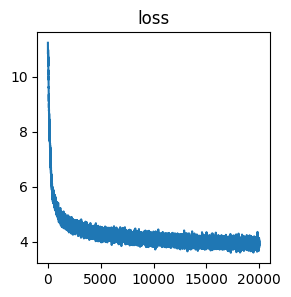

In [9]:
flow_matching.train(
    num_training_steps=20_000,
)
flow_matching.trainer.plot_training_logs()


### Generating Some Events.

In [10]:
samples = flow_matching.predict(
    batch={},
    batch_size=400_000,
)


### Defining function to visulize geenrated samples.

In [11]:
def concatenate_adata_and_plot(
    adata, samples, plot_pcs=True, plot_umap=True, subsample_size=0.1, coloring=["dataset_type"], key="X_pca", **kwargs
):
    obs = {"dataset_type": ["Real" for _ in range(adata.shape[0])] + ["Generated" for _ in range(samples.shape[0])], **kwargs}
    adata_generated = AnnData(X=np.concatenate([adata.obsm[key], samples], axis=0), obs=obs)
    adata_generated.obsm[key] = adata_generated.X.copy()

    if plot_umap:
        sc.pp.subsample(adata_generated, subsample_size)
        sc.pp.neighbors(adata_generated)
        sc.tl.umap(adata_generated)
        
    for color in coloring:
        if plot_pcs:
            sc.pl.embedding(adata_generated, basis=key, color=color)
        if plot_umap:
            sc.pl.umap(adata_generated, color=color)
    return adata_generated


### Visualizing the generated samples.


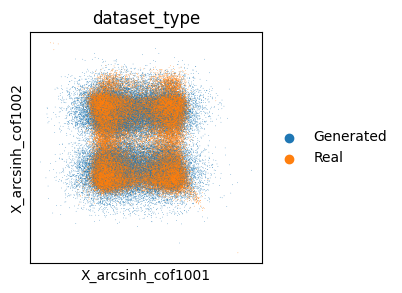

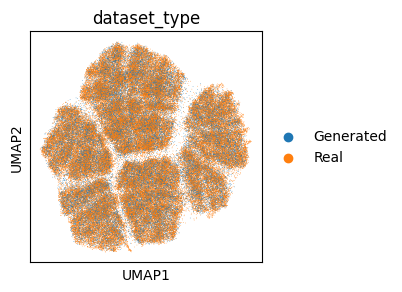

In [12]:
adata_generated = concatenate_adata_and_plot(
    adata,
    samples.cpu().numpy(),
    key=key_arcsin
)
